In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from utils import *

In [3]:
#Cargar modelo y scaler.
with open('../models/best_models/xgboost_best_model.pkl', 'rb') as f: 
    ml_model = pickle.load(f)
with open('../models/models_num/scaler_num.pkl', 'rb') as f:
    scaler = pickle.load(f)

C:\Users\franc\AppData\Local\Temp\ipykernel_10524\100448248.py:3: UserWarning: [17:44:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  ml_model = pickle.load(f)
c:\Users\franc\ENTORNO TRABAJO DATA y BI\IRONHACK\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainabil

In [ ]:
params = {
    'monthly_invest': 100, 
    'trade_amount': 150, 
    'take_profit_pct': 0.125, 
    'initial_trading_cash': 5000, 
    'verbose': True 
}

In [5]:
resultado_dow_jhon = pipeline_ticker(
    ticker='DIA', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params,
    strategy=backtest_dca_plus_trading_WITH_SL
)

Iniciando Pipeline para el ticker: {'DIA'}
---------------------------------------------
Resultados para: ml_signal (Con SL)
Valor Final del Portafolio: $47,753.82
Retorno Porcentual: 123.15%
Posiciones Abiertas al Final: 17
Valor de Posiciones Abiertas: $2,650.89
Sharpe Ratio: 1.22

Valor Final del Portafolio: $47,753.82
Total Aportado: $21,400.00

Trading PnL: $4,960.76
Capital Usado en Trading: $117,600.00

Total DCA Shares: 89.48

Pipeline para DIA completado.


In [6]:
resultado_SP500 = pipeline_ticker(
    ticker='VOO', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params,
    strategy=backtest_dca_plus_trading_WITH_SL)

Iniciando Pipeline para el ticker: {'VOO'}
---------------------------------------------
Resultados para: ml_signal (Con SL)
Valor Final del Portafolio: $58,056.94
Retorno Porcentual: 171.29%
Posiciones Abiertas al Final: 4
Valor de Posiciones Abiertas: $643.82
Sharpe Ratio: 1.35

Valor Final del Portafolio: $58,056.94
Total Aportado: $21,400.00

Trading PnL: $8,207.87
Capital Usado en Trading: $103,350.00

Total DCA Shares: 82.96

Pipeline para VOO completado.


Iniciando Pipeline para el ticker: {'QQQ'}
---------------------------------------------
Resultados para: ml_signal (Self-Sufficient)
Valor Final del Portafolio: $41,732.17
Total Aportado: $11,600.00
Retorno Absoluto: $30,132.17
Retorno Porcentual: 259.76%
Trading PnL: $1,618.71
Capital Usado en Trading: $23,700.00
Posiciones Abiertas al Final: 0
Valor de Posiciones Abiertas: $0.00
Total DCA Shares: 80.45
Valor DCA Shares: $41,713.46
Sharpe Ratio: 0.79



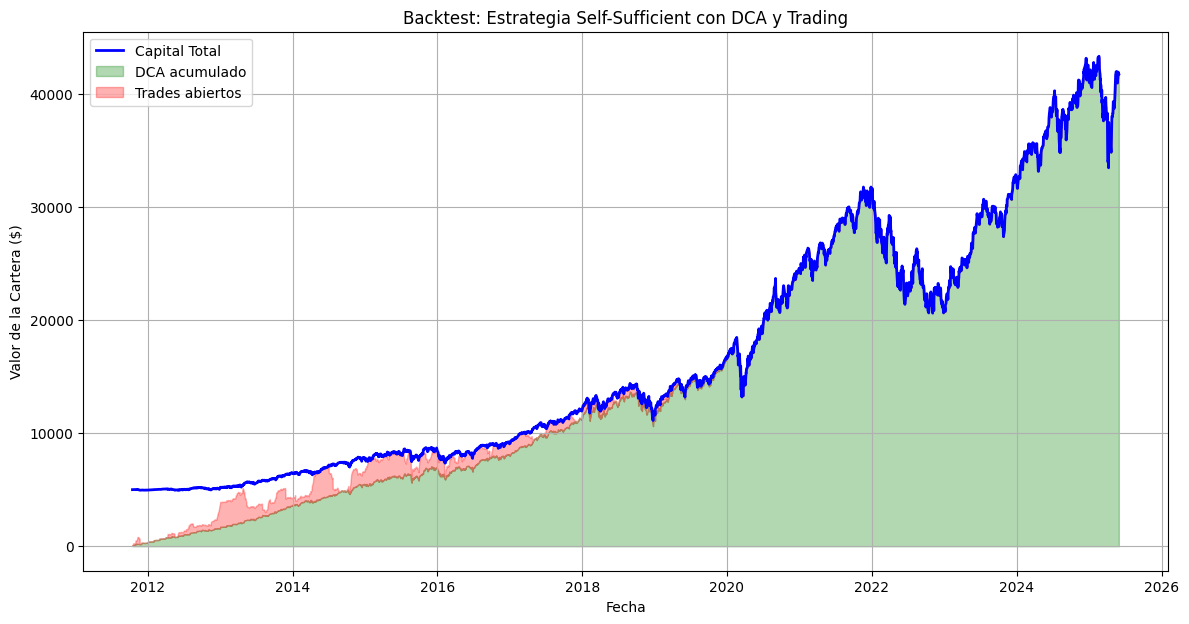

Pipeline para QQQ completado.


In [7]:
resultado_nasdaq = pipeline_ticker(
    ticker='QQQ', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params,
    strategy=backtest_dca_self_sufficient
)